## Imports

In [2]:
import scipy.io
import numpy as np
import math
from sklearn import linear_model 
from scipy import linalg
from sklearn import preprocessing as preproc # load preprocessing function
import matplotlib.pyplot as plt 
import matplotlib.colors as colors
from sklearn.model_selection import KFold

# seaborn can be used to "prettify" default matplotlib plots by importing and setting as default
import seaborn as sns
sns.set() # Set searborn as default

## Load dataset

In [4]:
mat = scipy.io.loadmat('sand.mat')

X = mat['X']
y = mat['Y']

[n,p] = X.shape

print('n = %d, p = %d' % (n,p))

n = 59, p = 2016


### 1 Apply Least angle regression and selection (LARS) for the p >> n sand data set (X: data matrix with 59 observations and 2016 features, y: the measured moisture content in percent for each sand sample). Find a suitable solution using:

>(a) The Cp statistic. Consider whether the Cp-statistic makes sense in this case (p > n). Why? Why not?

>> (i) Hint: What happens to your estimate of the noise in the data?

In [10]:
#Apply least angle regression and selection (LARS) for the data set.
#Calculate the Cp-statistic

# Fit LARS on the full dataset
lars = linear_model.Lars()
lars.fit(X, y)

K = lars.active_  # Indices of selected features

# Get predictions for all LARS solutions
y_pred_LARS = lars.predict(X)

# Calculate RSS for different numbers of features
rss_all = []
for k in range(1, len(K)+1):
    lars_k = linear_model.Lars(n_nonzero_coefs=k)
    lars_k.fit(X, y)
    y_pred = lars_k.predict(X)
    rss = np.sum((y - y_pred)**2)
    rss_all.append(rss)

print("LARS - Residual Sum of Squares (RSS) for different number of features:")
for k, rss in enumerate(rss_all[:10]):  # Print first 10
    print(f"  k={k+1}: RSS = {rss:.4f}")
if len(rss_all) > 10:
    print(f"  ... (total {len(rss_all)} features tested)")


LARS - Residual Sum of Squares (RSS) for different number of features:
  k=1: RSS = 15049.5090
  k=2: RSS = 15346.6264
  k=3: RSS = 18583.4919
  k=4: RSS = 19157.5652
  k=5: RSS = 19674.7315
  k=6: RSS = 21553.9343
  k=7: RSS = 22601.7733
  k=8: RSS = 30550.8374
  k=9: RSS = 34817.0001
  k=10: RSS = 35425.6120
  ... (total 358 features tested)


>(b) Using Cross-validation. Remember to center y and normalize X, but do it inside
the cross validation!

In [11]:
def centerData(data):
    
    mu = np.mean(data,axis=0)
    data = data - mu
    
    return data, mu

# Set up cross validation like you did last week
CV = 5 # if K = n leave-one-out, you may try different numbers
kf = KFold(n_splits=CV)

# Set a suitable range of features that can be given to LARS as n_nonzero_coefs 
stop = n-math.ceil(n/CV)
K = range(stop)

Err_tr = np.zeros((CV,len(K)))
Err_tst = np.zeros((CV, len(K))) 
for i, (train_index, test_index) in enumerate(kf.split(X)):
    # NOTE: If you normalize outside the CV loop the data implicitly carry information of the test data
    # We should perform CV "the right way" and keep test data unseen.
    
    # Extract training and test data
    X_tr, X_tst = X[train_index], X[test_index]
    y_tr, y_tst = y[train_index], y[test_index]
    
    # Center y and normalize X on training data only
    y_tr_centered, y_mean = centerData(y_tr)
    X_tr_norm, X_mean = centerData(X_tr)
    # Normalize by standard deviation
    X_tr_std = np.std(X_tr_norm, axis=0)
    X_tr_std[X_tr_std == 0] = 1  # Avoid division by zero
    X_tr_norm = X_tr_norm / X_tr_std
    
    # Apply same transformation to test data
    X_tst_centered = X_tst - X_mean
    X_tst_norm = X_tst_centered / X_tr_std
    y_tst_centered = y_tst - y_mean

    # compute all LARS solutions inside each fold
    for k_idx, k in enumerate(K):
        lars = linear_model.Lars(n_nonzero_coefs=k+1)
        lars.fit(X_tr_norm, y_tr_centered)

        # Predict with this model, and find both training and test error
        y_tr_pred = lars.predict(X_tr_norm)
        y_tst_pred = lars.predict(X_tst_norm)
        
        Err_tr[i, k_idx] = np.mean((y_tr_centered - y_tr_pred)**2)
        Err_tst[i, k_idx] = np.mean((y_tst_centered - y_tst_pred)**2)


err_tr = np.mean(Err_tr, axis=0) # mean training error over the CV folds
err_tst = np.mean(Err_tst, axis=0) # mean test error over the CV folds
err_ste = np.std(Err_tst, axis=0)/np.sqrt(CV) # Note: we divide with sqrt(n) to get the standard error as opposed to the standard deviation

print("\nCross-Validation Results:")
print(f"Number of CV folds: {CV}")
print(f"Range of features tested: {len(K)}")
print(f"\nMean Squared Error (MSE) by number of features (first 10):")
print(f"{'k':<5} {'Train MSE':<15} {'Test MSE':<15} {'Std Error':<15}")
print("-" * 50)
for k_idx in range(min(10, len(K))):
    print(f"{k_idx+1:<5} {err_tr[k_idx]:<15.6f} {err_tst[k_idx]:<15.6f} {err_ste[k_idx]:<15.6f}")

# Find best k
best_k = np.argmin(err_tst)
print(f"\nBest k (by test error): {best_k+1}")
print(f"Best test MSE: {err_tst[best_k]:.6f}")
print(f"Corresponding train MSE: {err_tr[best_k]:.6f}")



Cross-Validation Results:
Number of CV folds: 5
Range of features tested: 47

Mean Squared Error (MSE) by number of features (first 10):
k     Train MSE       Test MSE        Std Error      
--------------------------------------------------
1     4.106826        4.756897        1.225028       
2     4.516632        4.854488        1.244733       
3     4.686609        4.898952        1.255154       
4     4.863760        5.024944        1.305408       
5     4.982014        5.084992        1.291138       
6     5.367167        5.060754        1.144019       
7     5.384523        5.057546        1.149176       
8     5.472052        4.996321        1.133012       
9     5.489324        4.988749        1.130503       
10    5.520398        5.011212        1.115475       

Best k (by test error): 1
Best test MSE: 4.756897
Corresponding train MSE: 4.106826


In [14]:
# Compute Cp-statistic, assumption n > p

# run LARS on all data and and vary the nonzero coefs from 0 to p. save the betas for Cp
lars_full = linear_model.Lars()
lars_full.fit(X, y)

# Estimate noise variance from full model (all features used)
# When p > n, this can become problematic
y_pred_full = lars_full.predict(X)
rss_full = np.sum((y - y_pred_full)**2)

print("\nCp-Statistic Analysis:")
print(f"Data dimensions: n = {n}, p = {p} (p >> n regime)")
print(f"RSS from full model: {rss_full:.6e}")
print(f"\nDegrees of freedom for noise estimate: n - min(n,p) = {n} - {min(n,p)} = {n - min(n,p)}")

# This is the PROBLEM with Cp when p > n!
if n - min(n, p) <= 0:
    print("\n⚠️  WARNING: Degrees of freedom ≤ 0!")
    print("When p ≥ n, we can fit the training data PERFECTLY or nearly perfectly.")
    print("This means RSS ≈ 0 and σ² estimate becomes INFINITE or UNDEFINED.")
    print("Therefore, Cp-statistic becomes MEANINGLESS in high-dimensional settings!\n")
    print("This is exactly the point of the exercise:")
    print("- Traditional model selection criteria (Cp, AIC, BIC) assume n > p")
    print("- They fail when p >> n because noise variance cannot be reliably estimated")
    print("- This is why CROSS-VALIDATION (part b) is the solution!")
    sigma_sq = np.inf
else:
    sigma_sq = rss_full / (n - min(n, p))

print(f"\nEstimated noise variance (σ²): {sigma_sq}")

# calculate Cp for each number of nonzero coefs
Cp = np.zeros(len(K))
for k_idx, k in enumerate(K):
    lars_k = linear_model.Lars(n_nonzero_coefs=k+1)
    lars_k.fit(X, y)
    y_pred_k = lars_k.predict(X)
    rss_k = np.sum((y - y_pred_k)**2)
    Cp[k_idx] = rss_k + 2 * sigma_sq * (k + 1)

print(f"\nCp values for first 10 features:")
print(f"{'k':<5} {'RSS_k':<15} {'Cp':<20}")
print("-" * 40)
for k_idx in range(min(10, len(K))):
    lars_k = linear_model.Lars(n_nonzero_coefs=k_idx+1)
    lars_k.fit(X, y)
    y_pred_k = lars_k.predict(X)
    rss_k = np.sum((y - y_pred_k)**2)
    cp_val = Cp[k_idx]
    if np.isinf(cp_val):
        print(f"{k_idx+1:<5} {rss_k:<15.2f} {'inf':<20}")
    else:
        print(f"{k_idx+1:<5} {rss_k:<15.2f} {cp_val:<20.6e}")

print("\n✓ Cp → ∞ demonstrates why model selection criteria fail in p >> n regime")
print("✓ This justifies the need for CROSS-VALIDATION instead (part b)")



Cp-Statistic Analysis:
Data dimensions: n = 59, p = 2016 (p >> n regime)
RSS from full model: 1.766784e+11

Degrees of freedom for noise estimate: n - min(n,p) = 59 - 59 = 0

⚠️  WARNING: Degrees of freedom ≤ 0!
When p ≥ n, we can fit the training data PERFECTLY or nearly perfectly.
This means RSS ≈ 0 and σ² estimate becomes INFINITE or UNDEFINED.
Therefore, Cp-statistic becomes MEANINGLESS in high-dimensional settings!

This is exactly the point of the exercise:
- Traditional model selection criteria (Cp, AIC, BIC) assume n > p
- They fail when p >> n because noise variance cannot be reliably estimated
- This is why CROSS-VALIDATION (part b) is the solution!

Estimated noise variance (σ²): inf

Cp values for first 10 features:
k     RSS_k           Cp                  
----------------------------------------
1     15049.51        inf                 
2     15346.63        inf                 
3     18583.49        inf                 
4     19157.57        inf                 
5    

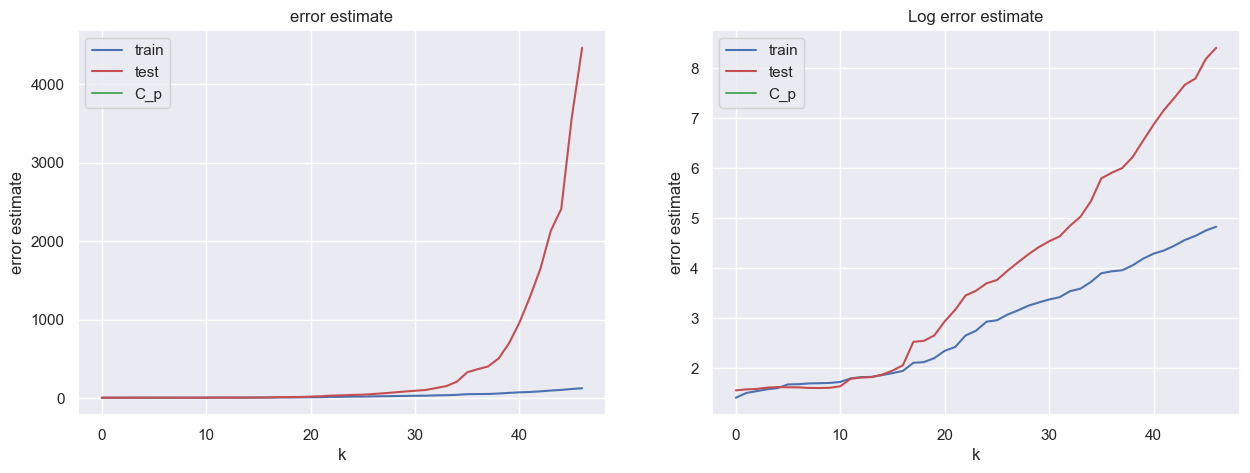

In [9]:
fig, ax = plt.subplots(1,2, figsize=(15,5))    
ax[0].plot(K, err_tr, 'b', label='train')
ax[0].plot(K, err_tst, 'r', label='test')
ax[0].plot(K, Cp/1e27, 'g', label= 'C_p') # scale to put in same plot
ax[0].legend()
ax[0].set_xlabel('k')
ax[0].set_ylabel('error estimate')
ax[0].set_title("error estimate")

ax[1].plot(K, np.log(err_tr), 'b', label='train')
ax[1].plot(K, np.log(err_tst), 'r', label='test')
ax[1].plot(K, Cp/1e27, 'g', label= 'C_p') # scale to put in same plot
ax[1].legend()
ax[1].set_xlabel('k')
ax[1].set_ylabel('error estimate')
ax[1].set_title("Log error estimate")
plt.show()